# 03 Modeling: Reparameterized Log-Skew-t Baseline Model

This notebook implements the methodology outlined for Section 4 of the project report. It uses the cleaned BCA outputs to fit a reparameterized log-skew-t model for baseline noise and stops before the real-experiment correction/reversal step.

The modeling goal is to estimate dwell-time-specific BCA noise distributions for the Prisma Pro dwell-time grid:

```text
0.128, 0.256, 0.512, 1.024, 2.048, 4.096 seconds
```

The reparameterized model is:


$$\log(Y_i) \sim \text{Skew-t}(\mu_\text{BCA}(d_i), \sigma_\text{BCA}(d_i), \alpha, \nu_\text{BCA}(d_i))$$

where $\mu_\text{BCA}(d_i)$, $\sigma_\text{BCA}(d_i)$, and $\nu_\text{BCA}(d_i)$ are smooth functions of $\log(d_i)$ estimated by maximum likelihood from the BCA data, while $\alpha$ is shared across dwell times. This keeps dwell-time-specific center, spread, and tail weight while reducing instability in the skewness parameter.

The main diagnostic visualizations compare, for each dwell time:

- raw observed BCA data,
- a KDE estimate from the observed data,
- the fitted reparameterized log-skew-t density.


## 1. Setup and Cleaned BCA Outputs

This notebook expects the cleaned preprocessing outputs already present in the project folder:

- `bca_long.csv`
- `bca_wide.csv`
- `dataframes.pkl`

Only BCA data are modeled here. Real experimental files are not corrected in this notebook.


In [1]:

from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize, stats

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

ROOT = Path.cwd()
BCA_LONG_PATH = ROOT / "bca_long.csv"
BCA_WIDE_PATH = ROOT / "bca_wide.csv"
DATAFRAMES_PATH = ROOT / "dataframes.pkl"

required = [BCA_LONG_PATH, BCA_WIDE_PATH, DATAFRAMES_PATH]
missing = [p.name for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing preprocessing output(s): " + ", ".join(missing) +
        ". Run 01-preprocessing.ipynb before this notebook."
    )

bca_long = pd.read_csv(BCA_LONG_PATH)
bca_wide = pd.read_csv(BCA_WIDE_PATH)
with open(DATAFRAMES_PATH, "rb") as f:
    preprocessing = pickle.load(f)

print(f"bca_long: {bca_long.shape}")
print(f"bca_wide: {bca_wide.shape}")
print(f"preprocessing metadata keys: {sorted(preprocessing.keys())}")

bca_long: (492000, 7)
bca_wide: (82000, 10)
preprocessing metadata keys: ['PRO_DWELL_TIMES', 'bca_keys', 'bca_metadata', 'bca_wide', 'dataframes', 'errors', 'exp_keys', 'invalid_negative_counts', 'pbca_skipped', 'total_invalid_negative_values']


## 2. Validate and Prepare Model Data

The log-skew-t model is fit on positive BCA intensities. Non-positive observations are excluded before the log transform and should be investigated in preprocessing if they appear.


In [2]:

expected_long_cols = {"lab", "set", "run_id", "dwell_time", "amu", "time_sec", "intensity"}
missing_cols = expected_long_cols.difference(bca_long.columns)
if missing_cols:
    raise ValueError(f"bca_long.csv is missing expected columns: {sorted(missing_cols)}")

bca_long = bca_long.copy()
bca_long["dwell_time"] = pd.to_numeric(bca_long["dwell_time"], errors="coerce")
bca_long["intensity"] = pd.to_numeric(bca_long["intensity"], errors="coerce")

initial_n = len(bca_long)
bca_long = bca_long.dropna(subset=["dwell_time", "intensity"])
nonpositive_n = int((bca_long["intensity"] <= 0).sum())
if nonpositive_n:
    warnings.warn(
        f"Dropping {nonpositive_n:,} non-positive observations before log transform. "
        "These should be checked against the preprocessing reversal logic."
    )
    bca_long = bca_long.loc[bca_long["intensity"] > 0].copy()

bca_long["log_intensity"] = np.log(bca_long["intensity"])
bca_long["log10_intensity"] = np.log10(bca_long["intensity"])

dwell_times = np.array(sorted(bca_long["dwell_time"].unique()), dtype=float)

print(f"Rows loaded:      {initial_n:,}")
print(f"Rows modeled:     {len(bca_long):,}")
print(f"Non-positive:     {nonpositive_n:,}")
print(f"Dwell times:      {dwell_times}")
print(f"Labs:             {sorted(bca_long['lab'].dropna().unique())}")
print(f"Unique BCA runs:  {bca_long['run_id'].nunique():,}")

Rows loaded:      492,000
Rows modeled:     491,997
Non-positive:     3
Dwell times:      [0.128 0.256 0.512 1.024 2.048 4.096]
Labs:             ['glasgow', 'nineamu', 'salzburg', 'wuhan']
Unique BCA runs:  71


C:\Users\Austin\AppData\Local\Temp\ipykernel_14168\4008494688.py:14: UserWarning: Dropping 3 non-positive observations before log transform. These should be checked against the preprocessing reversal logic.
  warnings.warn(


## 3. Compute Empirical Starting Values

The maximum likelihood fit estimates location, scale, skewness, and tail-heaviness directly from the log-skew-t likelihood. Empirical summaries of `log(Y)` are used only as stable optimizer starting values and diagnostics, not as final parameter estimates.


In [3]:
empirical_start = (
    bca_long.groupby("dwell_time", as_index=False)
    .agg(
        n=("log_intensity", "size"),
        empirical_mu=("log_intensity", "mean"),
        empirical_sigma=("log_intensity", "std"),
        median_amp=("intensity", "median"),
        mean_amp=("intensity", "mean"),
        sd_amp=("intensity", "std"),
        q05=("intensity", lambda s: s.quantile(0.05)),
        q95=("intensity", lambda s: s.quantile(0.95)),
    )
    .sort_values("dwell_time")
    .reset_index(drop=True)
)

if (empirical_start["empirical_sigma"] <= 0).any():
    raise ValueError("At least one dwell time has non-positive log-scale standard deviation.")

empirical_start


,dwell_time,n,empirical_mu,empirical_sigma,median_amp,mean_amp,sd_amp,q05,q95
0,0.128,81998,-31.341659,1.165773,2.985807e-14,3.927833e-14,3.486792e-14,2.765879e-15,1.084020e-13
1,0.256,82000,-31.781175,1.148999,1.955941e-14,2.489833e-14,2.138925e-14,1.779763e-15,6.661927e-14
2,0.512,81999,-32.224517,1.130259,1.266226e-14,1.564969e-14,1.291974e-14,1.183827e-15,4.080873e-14
3,1.024,82000,-32.619633,1.103746,8.606873e-15,1.025197e-14,7.973208e-15,8.184401e-16,2.556637e-14
4,2.048,82000,-32.939689,1.060225,6.362770e-15,7.162059e-15,5.127741e-15,6.331709e-16,1.664883e-14
5,4.096,82000,-33.143521,1.025829,5.255533e-15,5.642395e-15,3.703078e-15,5.546986e-16,1.224559e-14


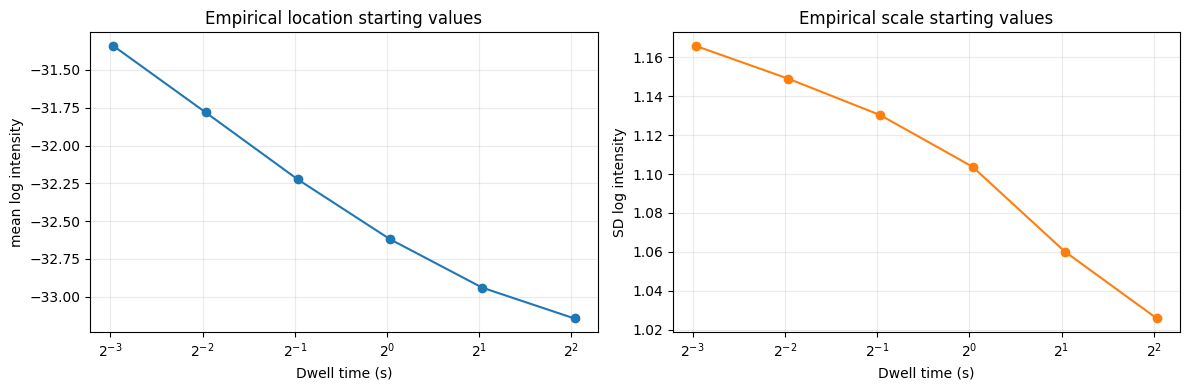

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(empirical_start["dwell_time"], empirical_start["empirical_mu"], marker="o")
axes[0].set_xscale("log", base=2)
axes[0].set_title("Empirical location starting values")
axes[0].set_xlabel("Dwell time (s)")
axes[0].set_ylabel("mean log intensity")

axes[1].plot(empirical_start["dwell_time"], empirical_start["empirical_sigma"], marker="o", color="tab:orange")
axes[1].set_xscale("log", base=2)
axes[1].set_title("Empirical scale starting values")
axes[1].set_xlabel("Dwell time (s)")
axes[1].set_ylabel("SD log intensity")

plt.tight_layout()
plt.show()


## 4. Fit Location, Scale, Shared Skewness, and Dwell-Dependent Tails by Maximum Likelihood

The model is fit directly to `log(Y)`. Location, scale, and tail-heaviness are estimated as smooth functions of dwell time rather than as empirical moments:

```text
mu_BCA(d) = beta_mu_0 + beta_mu_1 log(d)
log sigma_BCA(d) = beta_sigma_0 + beta_sigma_1 log(d)
log(nu_BCA(d) - 2) = beta_nu_0 + beta_nu_1 log(d)
```

A single skewness parameter `alpha` is shared across dwell times to avoid the skewness/tail degeneracy seen in unconstrained fits.

The optimized log-density for observation `i` is:

```text
z_i = (log(Y_i) - mu_BCA(d_i)) / sigma_BCA(d_i)
log f(log(Y_i)) = log f_skew_t(z_i; alpha, nu_BCA(d_i)) - log(sigma_BCA(d_i))
```

The scale and tail transformations keep the optimizer in the valid parameter space.


In [5]:
def skew_t_logpdf_standard(z, alpha, nu):
    """Standard Azzalini-style skew-t log-density for standardized z."""
    z = np.asarray(z, dtype=float)
    nu = np.asarray(nu, dtype=float)
    arg = alpha * z * np.sqrt((nu + 1.0) / (nu + z**2))
    return (
        np.log(2.0)
        + stats.t.logpdf(z, df=nu)
        + stats.t.logcdf(arg, df=nu + 1.0)
    )

model_data = bca_long[["dwell_time", "intensity", "log_intensity"]].copy()
x = model_data["log_intensity"].to_numpy(dtype=float)
log_d = np.log(model_data["dwell_time"].to_numpy(dtype=float))
log_d_mean = float(np.mean(np.log(dwell_times)))
log_d_scale = float(np.std(np.log(dwell_times), ddof=0))
log_d_std = (log_d - log_d_mean) / log_d_scale
x_grid = np.log(dwell_times)
x_grid_std = (x_grid - log_d_mean) / log_d_scale

mu_start_fit = np.polyfit(
    (np.log(empirical_start["dwell_time"].to_numpy(dtype=float)) - log_d_mean) / log_d_scale,
    empirical_start["empirical_mu"].to_numpy(dtype=float),
    deg=1,
)
sigma_start_fit = np.polyfit(
    (np.log(empirical_start["dwell_time"].to_numpy(dtype=float)) - log_d_mean) / log_d_scale,
    np.log(empirical_start["empirical_sigma"].to_numpy(dtype=float)),
    deg=1,
)

# np.polyfit returns slope then intercept; the optimizer uses intercept then slope.
base_start = np.array([
    mu_start_fit[1],
    mu_start_fit[0],
    sigma_start_fit[1],
    sigma_start_fit[0],
    0.0,
    np.log(12.0 - 2.0),
    0.0,
])


def unpack_params(theta):
    mu = theta[0] + theta[1] * log_d_std
    sigma = np.exp(theta[2] + theta[3] * log_d_std)
    alpha = theta[4]
    nu = 2.0 + np.exp(theta[5] + theta[6] * log_d_std)
    return mu, sigma, alpha, nu


def evaluate_functions(theta, grid_std=x_grid_std):
    mu = theta[0] + theta[1] * grid_std
    sigma = np.exp(theta[2] + theta[3] * grid_std)
    nu = 2.0 + np.exp(theta[5] + theta[6] * grid_std)
    return mu, sigma, nu


def negative_log_likelihood(theta, x):
    mu, sigma, alpha, nu = unpack_params(theta)
    z = (x - mu) / sigma
    ll = skew_t_logpdf_standard(z, alpha=alpha, nu=nu) - np.log(sigma)
    if not np.all(np.isfinite(ll)):
        return np.inf
    return -float(ll.sum())


starts = []
for alpha_start in [0.0, 0.05, -0.05]:
    for nu_start in [8.0, 12.0]:
        start = base_start.copy()
        start[4] = alpha_start
        start[5] = np.log(nu_start - 2.0)
        starts.append(start)

bounds = [
    (base_start[0] - 5.0, base_start[0] + 5.0),
    (base_start[1] - 5.0, base_start[1] + 5.0),
    (np.log(0.05), np.log(5.0)),
    (-2.0, 2.0),
    (-20.0, 20.0),
    (np.log(2.01 - 2.0), np.log(200.0 - 2.0)),
    (-2.0, 2.0),
]

fits = []
for start in starts:
    fit = optimize.minimize(
        negative_log_likelihood,
        start,
        args=(x,),
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500, "ftol": 1e-7},
    )
    fits.append(fit)

best = min(fits, key=lambda result: result.fun)
theta_hat = best.x
mu_grid, sigma_grid, nu_grid = evaluate_functions(theta_hat)
alpha_hat = theta_hat[4]
log_likelihood = -best.fun
n_obs = len(x)
k_params = len(theta_hat)


def _standardized_log_d(d):
    d = np.asarray(d, dtype=float)
    return (np.log(d) - log_d_mean) / log_d_scale


def mu_BCA(d):
    d_std = _standardized_log_d(d)
    return theta_hat[0] + theta_hat[1] * d_std


def sigma_BCA(d):
    d_std = _standardized_log_d(d)
    return np.exp(theta_hat[2] + theta_hat[3] * d_std)


def nu_BCA(d):
    d_std = _standardized_log_d(d)
    return 2.0 + np.exp(theta_hat[5] + theta_hat[6] * d_std)


model_data["mu_hat"] = mu_BCA(model_data["dwell_time"])
model_data["sigma_hat"] = sigma_BCA(model_data["dwell_time"])
model_data["nu_hat"] = nu_BCA(model_data["dwell_time"])
model_data["z"] = (model_data["log_intensity"] - model_data["mu_hat"]) / model_data["sigma_hat"]
z = model_data["z"].to_numpy(dtype=float)

calibration = pd.DataFrame({
    "dwell_time": dwell_times,
    "n": empirical_start["n"].to_numpy(dtype=int),
    "mu_BCA": mu_grid,
    "sigma_BCA": sigma_grid,
    "nu_BCA": nu_grid,
    "empirical_mu": empirical_start["empirical_mu"].to_numpy(dtype=float),
    "empirical_sigma": empirical_start["empirical_sigma"].to_numpy(dtype=float),
})

model_summary = pd.DataFrame({
    "parameter": [
        "mu_intercept", "mu_log_d_slope",
        "log_sigma_intercept", "log_sigma_log_d_slope",
        "alpha",
        "log_nu_minus_2_intercept", "log_nu_minus_2_log_d_slope",
        "log_likelihood", "AIC", "BIC", "n",
    ],
    "estimate": [
        theta_hat[0], theta_hat[1],
        theta_hat[2], theta_hat[3],
        alpha_hat,
        theta_hat[5], theta_hat[6],
        log_likelihood,
        2 * k_params - 2 * log_likelihood,
        np.log(n_obs) * k_params - 2 * log_likelihood,
        n_obs,
    ],
})

print(f"Optimizer success: {best.success}")
print(best.message)
print(f"Best objective from {len(fits)} starts: {best.fun:.2f}")
print(f"Failed starts: {sum(not fit.success for fit in fits)}")
display(model_summary)
calibration


C:\Users\Austin\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Optimizer success: True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Best objective from 6 starts: 675586.06
Failed starts: 0


,parameter,estimate
0,mu_intercept,-3.115298e+01
1,mu_log_d_slope,-7.131904e-01
2,log_sigma_intercept,2.967066e-01
3,log_sigma_log_d_slope,-1.236672e-01
4,alpha,-3.805560e+00
5,log_nu_minus_2_intercept,1.521617e+00
6,log_nu_minus_2_log_d_slope,-4.052800e-01
7,log_likelihood,-6.755861e+05
8,AIC,1.351186e+06
9,BIC,1.351264e+06


,dwell_time,n,mu_BCA,sigma_BCA,nu_BCA,empirical_mu,empirical_sigma
0,0.128,81998,-30.108978,1.612421,10.288643,-31.341659,1.165773
1,0.256,82000,-30.526579,1.499789,8.537656,-31.781175,1.148999
2,0.512,81999,-30.944181,1.395025,7.156566,-32.224517,1.130259
3,1.024,82000,-31.361782,1.297579,6.067234,-32.619633,1.103746
4,2.048,82000,-31.779384,1.206940,5.208025,-32.939689,1.060225
5,4.096,82000,-32.196985,1.122632,4.530325,-33.143521,1.025829


## 5. Fitted Density Helpers

The fitted log-skew-t density on the original ampere scale is evaluated by applying the standardized skew-t density, the dwell-specific `nu_BCA(d)`, and the log-transform Jacobian.

In [6]:
def log_skew_t_logpdf_y(y, d, alpha=alpha_hat, nu=None):
    y = np.asarray(y, dtype=float)
    d = np.asarray(d, dtype=float)
    mu = mu_BCA(d)
    sigma = sigma_BCA(d)
    nu_value = nu_BCA(d) if nu is None else nu
    z_y = (np.log(y) - mu) / sigma
    return skew_t_logpdf_standard(z_y, alpha=alpha, nu=nu_value) - np.log(sigma) - np.log(y)

def log_skew_t_pdf_y(y, d, alpha=alpha_hat, nu=None):
    return np.exp(log_skew_t_logpdf_y(y, d, alpha=alpha, nu=nu))

def log_skew_t_pdf_log10_x(x_log10, d, alpha=alpha_hat, nu=None):
    """Density of X = log10(Y), useful for overlaying on log10 histograms."""
    y = np.power(10.0, x_log10)
    return log_skew_t_pdf_y(y, d, alpha=alpha, nu=nu) * y * np.log(10.0)

def fitted_log_skew_t_cdf_y(y, d, alpha=alpha_hat, nu=None):
    """Approximate fitted CDF for y values at a single dwell time."""
    y = np.asarray(y, dtype=float)
    scalar_input = y.ndim == 0
    y_flat = np.atleast_1d(y).astype(float)
    d_value = float(np.asarray(d, dtype=float).ravel()[0])
    mu = float(mu_BCA(d_value))
    sigma = float(sigma_BCA(d_value))
    nu_value = float(nu_BCA(d_value) if nu is None else np.asarray(nu, dtype=float).ravel()[0])
    z_eval = (np.log(y_flat) - mu) / sigma

    z_min = min(-40.0, float(np.nanmin(z_eval)) - 5.0)
    z_max = max(40.0, float(np.nanmax(z_eval)) + 5.0)
    z_grid = np.linspace(z_min, z_max, 8000)
    pdf_grid = np.exp(skew_t_logpdf_standard(z_grid, alpha=alpha, nu=nu_value))
    cdf_grid = np.r_[0.0, np.cumsum((pdf_grid[:-1] + pdf_grid[1:]) * np.diff(z_grid) / 2.0)]
    cdf_grid = cdf_grid / cdf_grid[-1]
    cdf_values = np.interp(z_eval, z_grid, cdf_grid, left=0.0, right=1.0)
    return float(cdf_values[0]) if scalar_input else cdf_values.reshape(y.shape)

def simulate_standard_skew_t(size, alpha=alpha_hat, nu=None, d=None, random_state=192):
    rng = np.random.default_rng(random_state)
    nu_value = float(nu if nu is not None else nu_BCA(d if d is not None else dwell_times[0]))
    delta = alpha / np.sqrt(1.0 + alpha**2)
    u0 = rng.normal(size=size)
    u1 = rng.normal(size=size)
    w = rng.chisquare(df=nu_value, size=size)
    return (delta * np.abs(u0) + np.sqrt(1.0 - delta**2) * u1) / np.sqrt(w / nu_value)

## 6. Raw Data, KDE, and Log-Skew-t by Dwell Time

Each panel compares three views of the same dwell-time distribution on the `log10(intensity)` scale:

- gray bars: raw observed BCA data,
- blue curve: KDE fitted directly to the observed log10 intensities,
- red curve: fitted reparameterized log-skew-t density.

The log10 scale is used because the original ampere-scale distributions have sharp near-zero concentration and long upper tails.


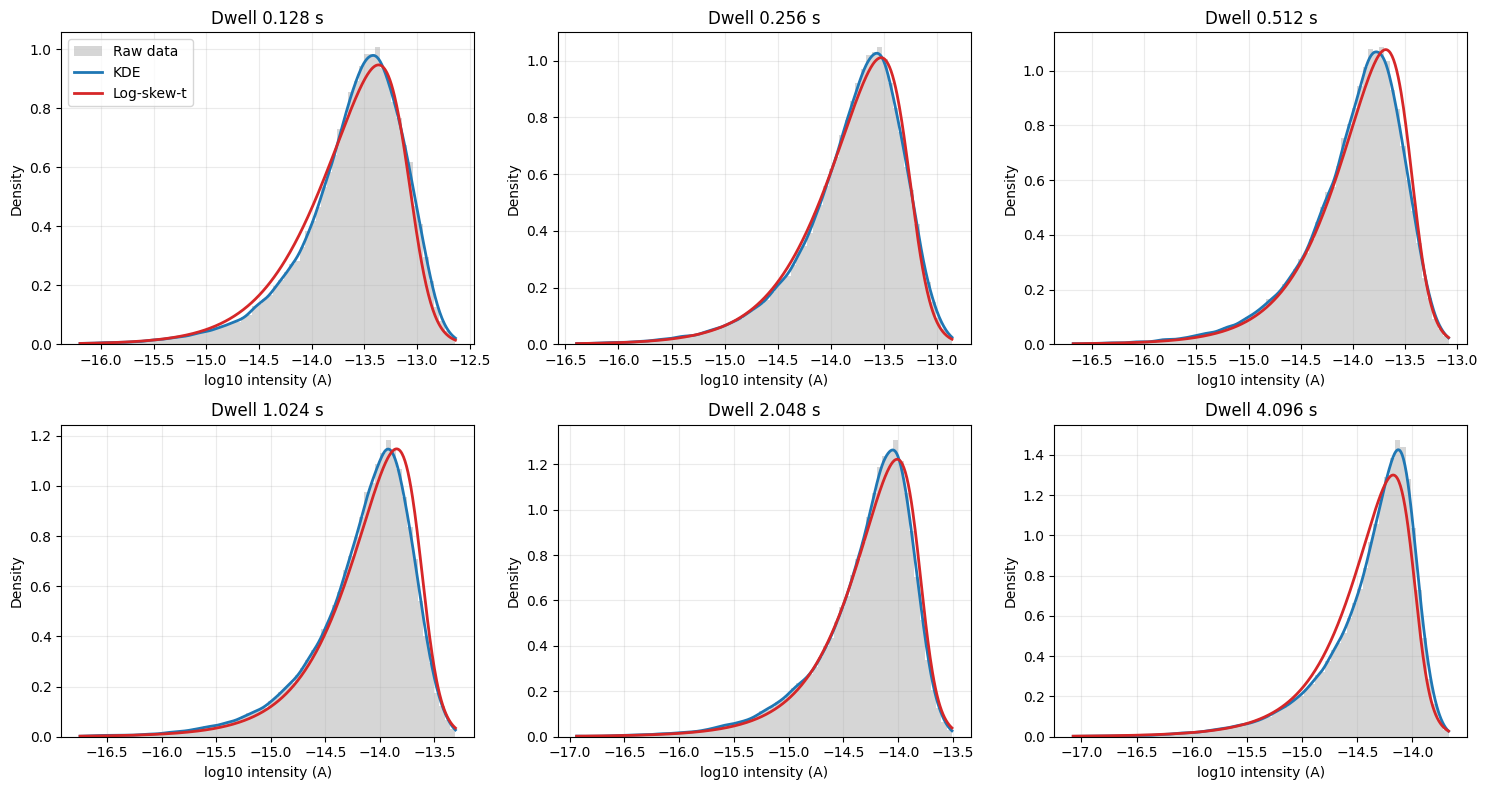

,dwell_time,kde_peak_log10,fit_peak_log10,mean_abs_density_gap,max_abs_density_gap
0,0.128,-13.412792,-13.362814,0.025165,0.100490
1,0.256,-13.564625,-13.522068,0.013840,0.073592
2,0.512,-13.773822,-13.687249,0.020808,0.155876
3,1.024,-13.920824,-13.844967,0.029478,0.192964
4,2.048,-14.051683,-14.010478,0.019281,0.136306
5,4.096,-14.129340,-14.177057,0.040103,0.215247


In [7]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.ravel()
comparison_rows = []

for ax, dwell in zip(axes, dwell_times):
    observed_log10 = bca_long.loc[bca_long["dwell_time"] == dwell, "log10_intensity"].to_numpy(dtype=float)
    lo, hi = np.quantile(observed_log10, [0.001, 0.999])
    grid = np.linspace(lo, hi, 500)

    kde = stats.gaussian_kde(observed_log10)
    kde_density = kde(grid)
    fit_density = log_skew_t_pdf_log10_x(grid, dwell)

    ax.hist(observed_log10, bins=70, range=(lo, hi), density=True, alpha=0.35, color="0.55", label="Raw data")
    ax.plot(grid, kde_density, color="tab:blue", lw=2, label="KDE")
    ax.plot(grid, fit_density, color="tab:red", lw=2, label="Log-skew-t")
    ax.set_title(f"Dwell {dwell:g} s")
    ax.set_xlabel("log10 intensity (A)")
    ax.set_ylabel("Density")

    comparison_rows.append({
        "dwell_time": dwell,
        "kde_peak_log10": grid[np.argmax(kde_density)],
        "fit_peak_log10": grid[np.argmax(fit_density)],
        "mean_abs_density_gap": float(np.mean(np.abs(kde_density - fit_density))),
        "max_abs_density_gap": float(np.max(np.abs(kde_density - fit_density))),
    })

axes[0].legend()
plt.tight_layout()
plt.show()

comparison_summary = pd.DataFrame(comparison_rows)
comparison_summary

## 7. Original-Scale Comparison

These panels show the same comparison on the original ampere scale, truncated at the 99.5th percentile within each dwell time so the central mass of the distribution is readable.


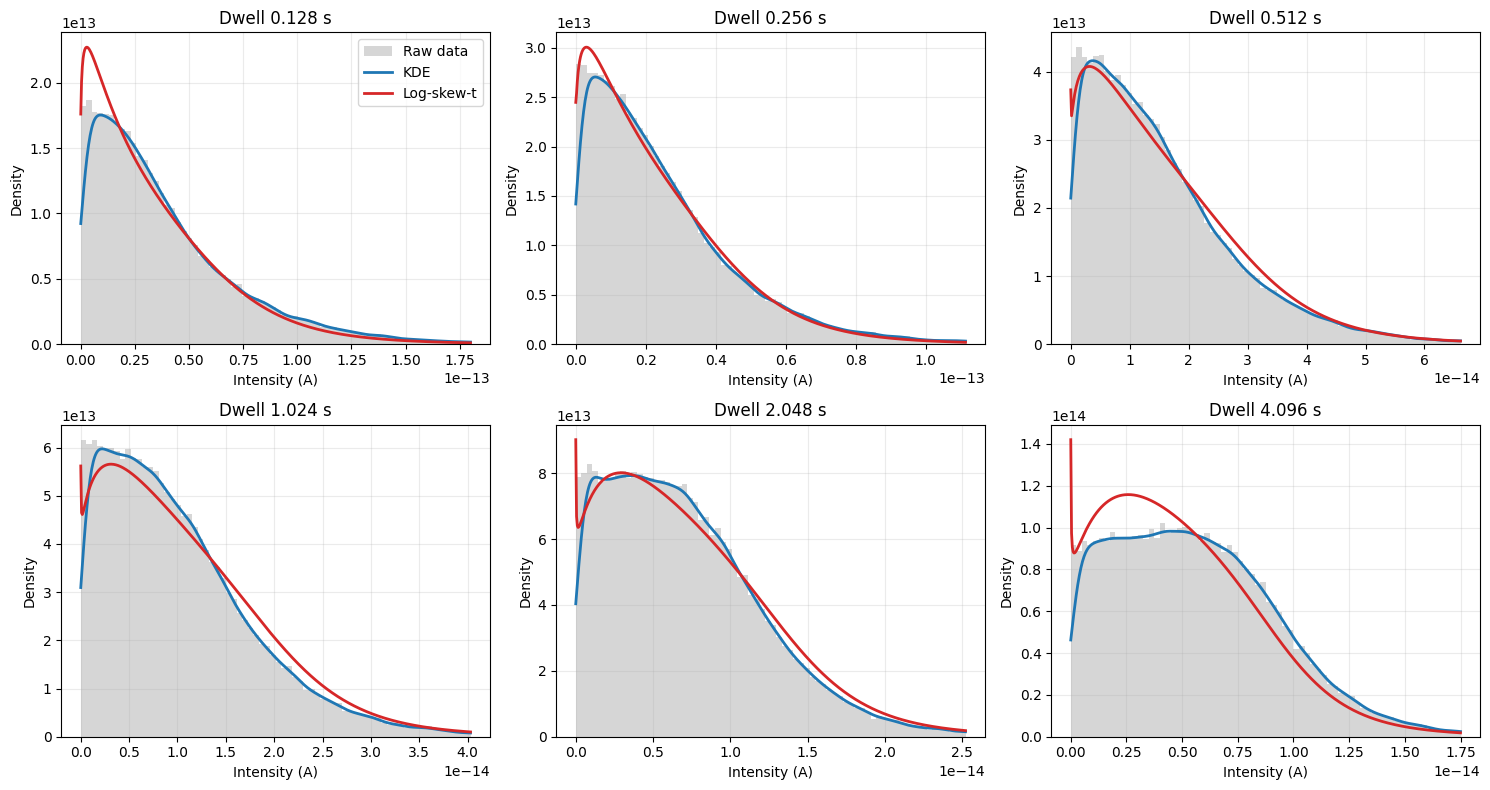

In [8]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.ravel()

for ax, dwell in zip(axes, dwell_times):
    observed = bca_long.loc[bca_long["dwell_time"] == dwell, "intensity"].to_numpy(dtype=float)
    upper = np.quantile(observed, 0.995)
    lower = max(np.quantile(observed, 0.001), np.finfo(float).tiny)
    grid = np.linspace(lower, upper, 500)

    kde = stats.gaussian_kde(observed)
    ax.hist(observed[(observed >= lower) & (observed <= upper)], bins=70, density=True, alpha=0.35, color="0.55", label="Raw data")
    ax.plot(grid, kde(grid), color="tab:blue", lw=2, label="KDE")
    ax.plot(grid, log_skew_t_pdf_y(grid, dwell), color="tab:red", lw=2, label="Log-skew-t")
    ax.set_title(f"Dwell {dwell:g} s")
    ax.set_xlabel("Intensity (A)")
    ax.set_ylabel("Density")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

axes[0].legend()
plt.tight_layout()
plt.show()

## 8. Standardized Residual Diagnostics

If `mu_BCA(d)` and `sigma_BCA(d)` capture the dwell-time structure, standardized residuals should have broadly similar center and scale across dwell times. The fitted model now allows the remaining tail behavior to vary through `nu_BCA(d)` while keeping `alpha` shared.

In [9]:

resid_summary = (
    model_data.assign(dwell_time=bca_long["dwell_time"].values)
    .groupby("dwell_time")
    .agg(
        n=("z", "size"),
        mean_z=("z", "mean"),
        sd_z=("z", "std"),
        skew_z=("z", lambda s: stats.skew(s, bias=False)),
        kurtosis_z=("z", lambda s: stats.kurtosis(s, fisher=True, bias=False)),
    )
    .reset_index()
)
resid_summary

,dwell_time,n,mean_z,sd_z,skew_z,kurtosis_z
0,0.128,81998,-0.764491,0.722995,-1.357499,4.131351
1,0.256,82000,-0.836515,0.766107,-1.354490,3.528888
2,0.512,81999,-0.917787,0.810206,-1.458823,4.330216
3,1.024,82000,-0.969383,0.850619,-1.559565,4.643682
4,2.048,82000,-0.961361,0.878440,-1.661622,4.594119
5,4.096,82000,-0.843139,0.913771,-1.924568,6.826557


## 9. Empirical CDF vs Fitted CDF

These plots compare cumulative probability directly on the `log10(intensity)` scale. The gray line is the empirical CDF from the raw BCA observations; the red line is the fitted log-skew-t CDF. This view shows where the fitted distribution accumulates probability too quickly or too slowly.


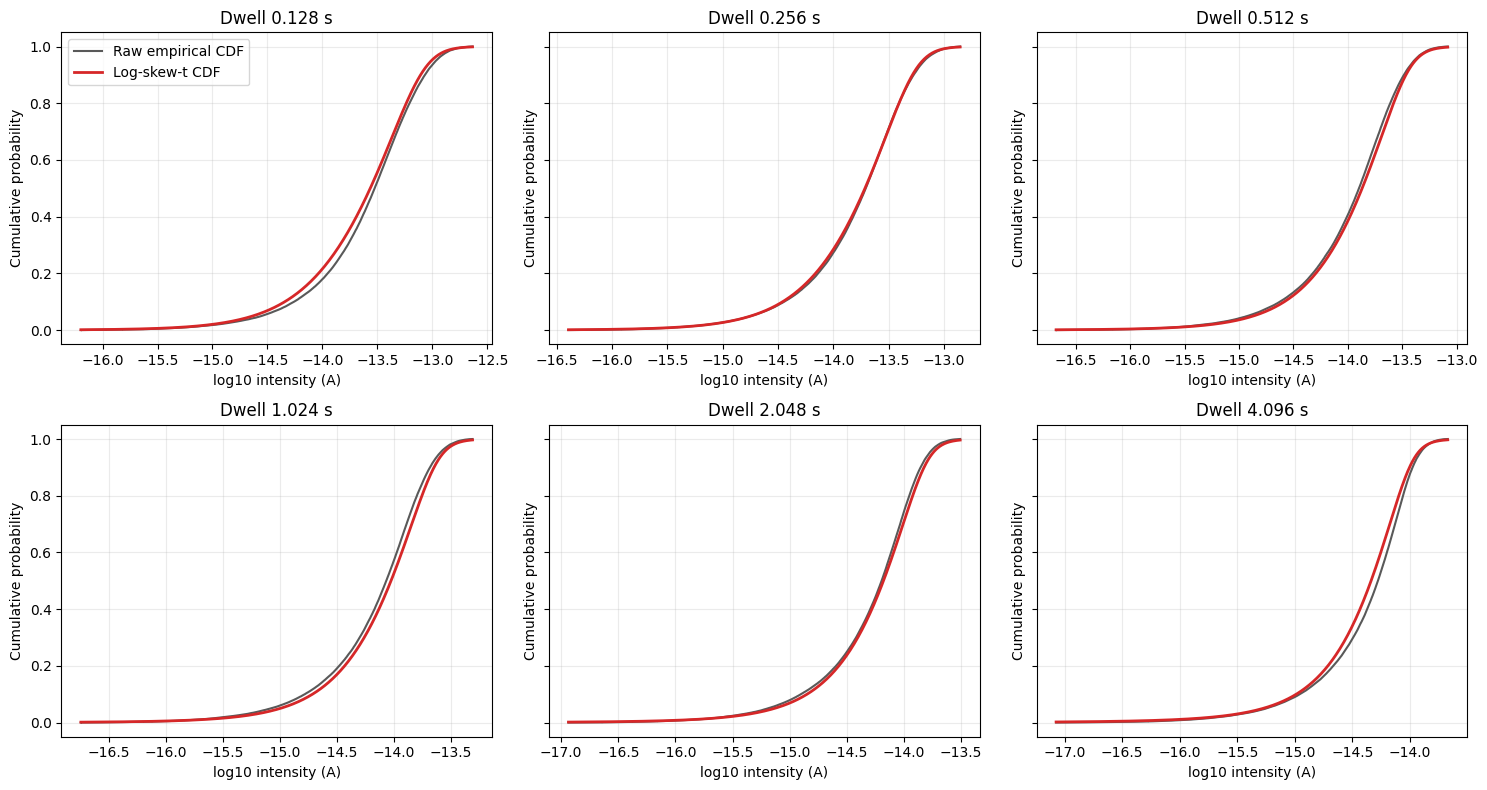

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.ravel()

for ax, dwell in zip(axes, dwell_times):
    observed_log10 = np.sort(bca_long.loc[bca_long["dwell_time"] == dwell, "log10_intensity"].to_numpy(dtype=float))
    lo, hi = np.quantile(observed_log10, [0.001, 0.999])
    grid_log10 = np.linspace(lo, hi, 600)
    grid_y = np.power(10.0, grid_log10)
    fitted_cdf = fitted_log_skew_t_cdf_y(grid_y, dwell)

    in_range = observed_log10[(observed_log10 >= lo) & (observed_log10 <= hi)]
    empirical_prob = np.arange(1, len(in_range) + 1) / (len(in_range) + 1)

    ax.plot(in_range, empirical_prob, color="0.35", lw=1.5, label="Raw empirical CDF")
    ax.plot(grid_log10, fitted_cdf, color="tab:red", lw=2, label="Log-skew-t CDF")
    ax.set_title(f"Dwell {dwell:g} s")
    ax.set_xlabel("log10 intensity (A)")
    ax.set_ylabel("Cumulative probability")

axes[0].legend()
plt.tight_layout()
plt.show()

In [11]:
print("Reparameterized log-skew-t MLE summary")
print("======================================")
print(f"Observations modeled: {n_obs:,}")
print(f"Dwell times: {', '.join(str(d) for d in dwell_times)}")
print(f"alpha_hat: {alpha_hat:.4f}")
print("mu_BCA(d), sigma_BCA(d), nu_BCA(d):")
for dwell, mu_value, sigma_value, nu_value in zip(dwell_times, mu_grid, sigma_grid, nu_grid):
    print(f"  {dwell:g} s: mu={mu_value:.4f}, sigma={sigma_value:.4f}, nu={nu_value:.4f}")
print(f"LogLik:    {log_likelihood:.2f}")
print(f"AIC:       {2 * k_params - 2 * log_likelihood:.2f}")
print(f"BIC:       {np.log(n_obs) * k_params - 2 * log_likelihood:.2f}")


Reparameterized log-skew-t MLE summary
Observations modeled: 491,997
Dwell times: 0.128, 0.256, 0.512, 1.024, 2.048, 4.096
alpha_hat: -3.8056
mu_BCA(d), sigma_BCA(d), nu_BCA(d):
  0.128 s: mu=-30.1090, sigma=1.6124, nu=10.2886
  0.256 s: mu=-30.5266, sigma=1.4998, nu=8.5377
  0.512 s: mu=-30.9442, sigma=1.3950, nu=7.1566
  1.024 s: mu=-31.3618, sigma=1.2976, nu=6.0672
  2.048 s: mu=-31.7794, sigma=1.2069, nu=5.2080
  4.096 s: mu=-32.1970, sigma=1.1226, nu=4.5303
LogLik:    -675586.06
AIC:       1351186.11
BIC:       1351263.86
